# 19 - Basis Blades and Operations

Source orientation: the PDF/page audit in this notebook records the printed and PDF page span used for chapter grounding; all prose, examples, visuals, and checks here are original course material.

This notebook is a standalone, executable replacement for Chapter 19 of *Geometric Algebra for Computer Science*. Its job is to make the lowest implementation layer visible: a basis blade becomes an integer bitmap, signs become swap parity, products become bit operations plus metric factors, and nonorthogonal metrics explain why a product that looked like one blade can become a small sum.

The notebook is written in the same spirit as the seed notebooks in this repository. It gives the idea first, translates the textbook notation into inspectable Python, creates artifacts under `artifacts/chapter-19`, and ends with sanity checks that can fail loudly if the implementation story stops matching the algebra.

Source audit before writing: the requested printed pages are 511-520. In this PDF, `pdftotext` extraction maps printed pages 511-519 to PDF pages 533-541. PDF page 542 begins printed page 521, so printed page 520 is a blank or otherwise unextracted interchapter page in this file. The explanations below are original and curated; they do not copy the book's prose or exercises.

## The Chapter Idea In One Picture

A multivector implementation eventually has to answer a tiny question many times: what happens when one weighted basis blade multiplies another? In an algebra with three basis vectors, the scalar, vectors, bivectors, and trivector can all be addressed by a bitmap:

- `000` means the scalar blade `1`;
- `001` means `e1`;
- `010` means `e2`;
- `101` means `e1^e3`;
- `111` means `e1^e2^e3`.

The least significant bit stands for `e1`, the next bit for `e2`, and so on. That ordering can feel backwards when you first look at a binary string, because `e1` is usually written at the left of a basis blade but is stored at the right of the integer. The payoff is that a computer can test for shared factors with `&`, combine independent factors with `^`, count grade with `bit_count()`, and keep a dense lookup table indexed by integers.

The subtle part is not finding the output bitmap. The subtle part is finding the sign. When the factors from the left blade and the right blade are concatenated, they may not be in canonical order. Every adjacent swap flips the sign. So `e3^e1` has the same bitmap as `e1^e3`, but the scale is negative. This is where the implementation becomes both efficient and easy to get wrong: a single missed inversion changes many products downstream.

The geometric product adds the metric. In an orthogonal metric, repeated basis vectors cancel into their diagonal squares, so `e2 e2` becomes `g22`, while the remaining unpaired bits still combine by exclusive-or. In a nonorthogonal metric, off-diagonal inner products add scalar or lower-grade pieces during multiplication. The result may no longer be a single basis blade. The notebook builds both cases so the difference is executable rather than just asserted.

## Translation Guide

| Mathematical idea | Implementation object in this notebook | Why it matters |
|---|---|---|
| Unit basis blade | `BasisBlade(bitmap, scale=1.0)` | Stores both the canonical blade identity and its coefficient. |
| Grade | `bitmap.bit_count()` | Counts how many basis vectors occur in a blade. |
| Shared basis vector factor | `left.bitmap & right.bitmap` | Detects outer-product dependence and repeated factors in a geometric product. |
| Canonical blade identity | `left.bitmap ^ right.bitmap` | Combines factors that remain after common factors are removed. |
| Outer-product sign | parity of swaps needed to sort concatenated factors | Encodes anticommutativity of independent basis vectors. |
| Orthogonal metric factor | product of diagonal entries for shared bits | Turns repeated vectors into their metric squares. |
| Nonorthogonal metric product | sparse dictionary `{bitmap: coefficient}` | Allows a product to expand into several grades or several blades. |
| Reversion, grade involution, Clifford conjugation | grade-dependent sign functions | Unary operations are cheap once grade is known. |

The helper module deliberately avoids a full symbolic algebra package. The goal is not to compete with a production geometric-algebra library. The goal is to expose the small set of operations that such a library would precompute or inline: bitmap decoding, swap parity, basis-blade products, sparse term cleanup, and grade projection.

The examples use labels like `e1^e2` instead of rendering every basis blade as a formal wedge expression. Read `^` here as the exterior product symbol, not Python exponentiation. The actual executable representation is the integer bitmap, and the label is just a human-readable view of the same bits.

## Notebook Route

1. Import the Chapter 19 helper module and create artifact directories.
2. Visualize bitmap encoding and check that grade is just a bit count.
3. Count swaps to recover signs for canonical ordering.
4. Build an outer-product table from bitwise dependence tests and exclusive-or.
5. Build geometric-product tables for orthogonal metrics and compare them with the general product engine.
6. Derive scalar and contraction-style products by grade selection.
7. Show why nonorthogonal metrics can produce sums of blades.
8. Run an applied sparse-multivector lab that distributes products over blade lists.
9. Check grade-dependent signs, common implementation pitfalls, and artifact existence.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from IPython.display import Image, display

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "chapter19_basis_blades.py").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.chapter19_basis_blades import (
    BasisBlade,
    basis_blade_geometric_product,
    basis_table,
    bitmap_string,
    bitmap_to_label,
    canonical_reordering_sign,
    clifford_conjugation_sign,
    commutator_blades,
    default_names,
    format_multivector,
    geometric_product_orthogonal,
    grade_involution_sign,
    grade_project,
    left_contraction_blades,
    multiply_multivectors,
    outer_product_blades,
    reversion_sign,
    scalar_product_blades,
    swap_pairs,
    terms_to_rows,
)

np.set_printoptions(precision=4, suppress=True)

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-19"
FIGURE_DIR = ARTIFACT_ROOT / "figures"
DATA_DIR = ARTIFACT_ROOT / "data"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for directory in (FIGURE_DIR, DATA_DIR, CHECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = {
    "printed_pages_requested": "511-520",
    "pdf_pages_extracted": "533-541",
    "note": "Printed page 520 is blank or unextracted; PDF page 542 begins printed page 521.",
}

def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()

def close_terms(left: dict[int, float], right: dict[int, float], tol: float = 1e-9) -> bool:
    keys = set(left) | set(right)
    return all(abs(left.get(key, 0.0) - right.get(key, 0.0)) <= tol for key in keys)

def blade_string(blade: BasisBlade, names: tuple[str, ...]) -> str:
    if blade.is_zero:
        return "0"
    return format_multivector({blade.bitmap: blade.scale}, names, precision=0)

print(json.dumps(SOURCE_SPAN, indent=2))
print(f"artifact root: {rel(ARTIFACT_ROOT)}")

{
  "printed_pages_requested": "511-520",
  "pdf_pages_extracted": "533-541",
  "note": "Printed page 520 is blank or unextracted; PDF page 542 begins printed page 521."
}
artifact root: artifacts/chapter-19


## Bitmap Encoding

The bitmap is the address of a basis blade. For a four-dimensional algebra, the possible addresses run from `0000` through `1111`. Every set bit says that the corresponding basis vector is present. A scalar has no set bits. A vector has one set bit. A bivector has two set bits, and so on.

This is a compact representation, but it also fixes a convention. Bit 0 is `e1`, bit 1 is `e2`, bit 2 is `e3`, and bit 3 is `e4`. When a binary string is printed in the usual most-significant-bit-first way, `e1` appears at the far right. That is not an algebraic reversal; it is just positional notation for an integer. The helper's labels always decode the bits back into canonical basis-vector order.

The next cell draws the complete four-dimensional table. The rows are basis blades, the columns are bit positions, and the color marks whether a bit is present. The table is small enough to inspect directly, but the same method works for any dimension that fits comfortably in a machine integer and in memory. The practical limit for a general dense multivector is usually the `2**n` number of coordinates, not the integer bitmap itself.

first eight rows:
0000  grade 0  1
0001  grade 1  e1
0010  grade 1  e2
0011  grade 2  e1^e2
0100  grade 1  e3
0101  grade 2  e1^e3
0110  grade 2  e2^e3
0111  grade 3  e1^e2^e3
saved artifacts/chapter-19/figures/bitmap-encoding.png


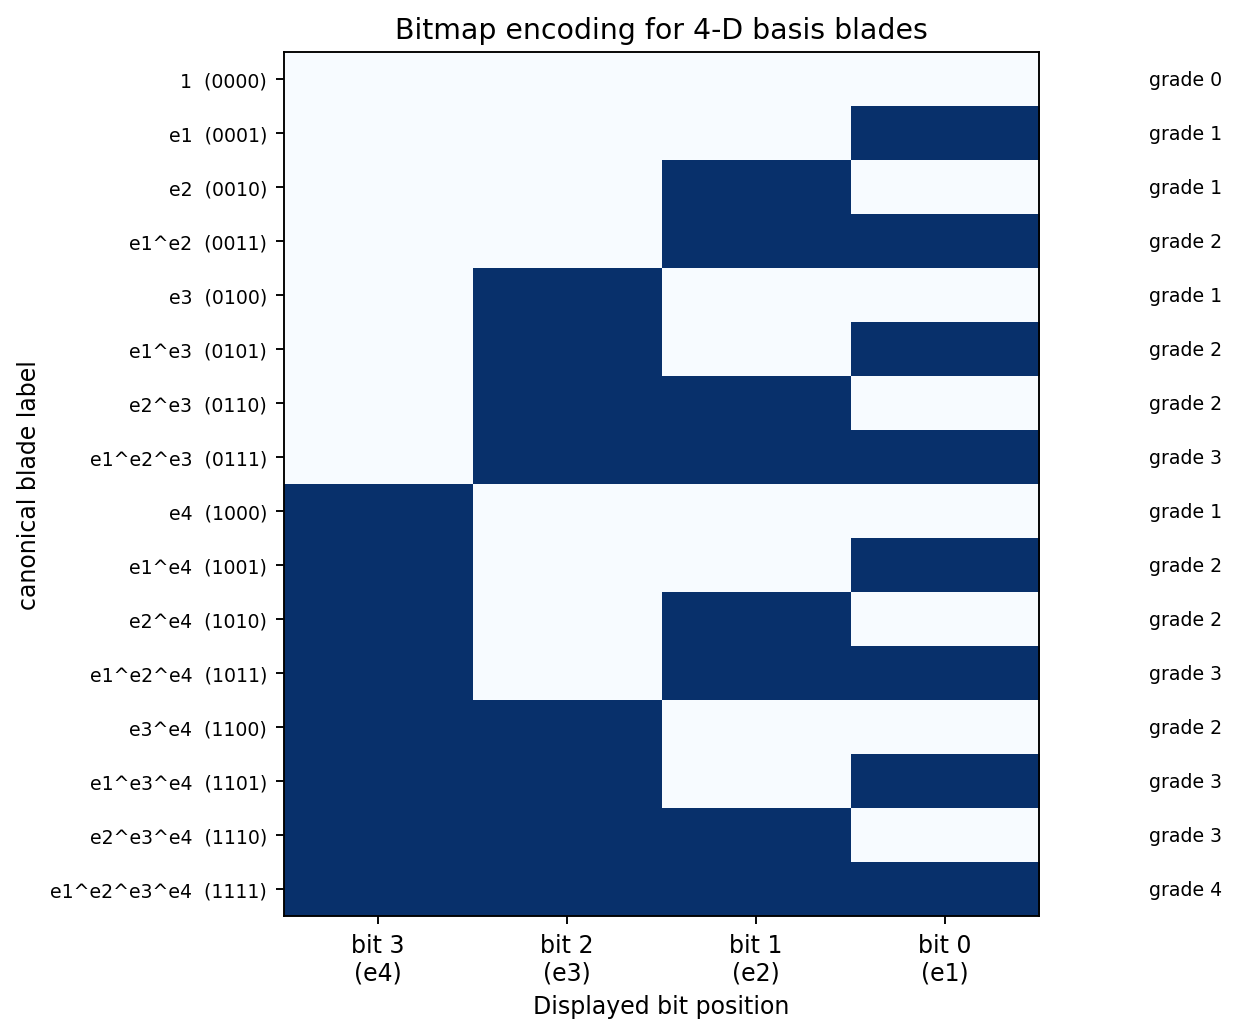

In [2]:
names4 = default_names(4)
rows4 = basis_table(4, names4)
bit_matrix = np.array([[int(ch) for ch in row["binary"]] for row in rows4], dtype=int)

fig, ax = plt.subplots(figsize=(7.6, 6.2))
ax.imshow(bit_matrix, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_title("Bitmap encoding for 4-D basis blades")
ax.set_xlabel("Displayed bit position")
ax.set_xticks(range(4), labels=["bit 3\n(e4)", "bit 2\n(e3)", "bit 1\n(e2)", "bit 0\n(e1)"])
ax.set_yticks(range(len(rows4)), labels=[f"{row['label']}  ({row['binary']})" for row in rows4])
ax.tick_params(axis="y", labelsize=8)
ax.set_ylabel("canonical blade label")
for y, row in enumerate(rows4):
    ax.text(4.08, y, f"grade {row['grade']}", va="center", fontsize=8)
fig.tight_layout()

bitmap_path = FIGURE_DIR / "bitmap-encoding.png"
fig.savefig(bitmap_path, dpi=170, bbox_inches="tight")
plt.close(fig)

assert all(row["grade"] == int(row["bitmap"]).bit_count() for row in rows4)
assert bitmap_to_label(0b0101, names4) == "e1^e3"
assert bitmap_string(0b0101, 4) == "0101"

print("first eight rows:")
for row in rows4[:8]:
    print(f"{row['binary']}  grade {row['grade']}  {row['label']}")
print(f"saved {rel(bitmap_path)}")
display(Image(filename=str(bitmap_path), width=760))

## Signs From Swaps

A bitmap records only the set of basis vectors in a blade. It does not remember whether a human wrote `e3^e1` or `e1^e3`. The implementation therefore stores every nonzero blade in canonical order and moves any noncanonical ordering into the scalar coefficient.

The sign rule is the usual anticommuting rule for independent basis vectors: every time two basis-vector factors swap positions, the sign flips. If the left operand contains `e3` and the right operand contains `e1`, then the concatenated product starts as `e3 e1`; sorting it into `e1 e3` takes one swap, so the canonical blade is `-e1^e3`. If the left operand is `e2^e3` and the right operand is `e1`, then `e1` has to move past both `e3` and `e2`; two swaps give a positive sign.

Counting swaps can be done with bit operations. For each set bit in the left bitmap, count the set bits in the right bitmap with lower index. The total number of such inversions is the number of swaps needed to canonicalize the concatenated factors. The figure below makes that parity visible for a few small cases.

e3 times e1: swaps=1 sign=-1 output=e1^e3
e2^e3 times e1: swaps=2 sign=+1 output=e1^e2^e3
e1^e3 times e2: swaps=1 sign=-1 output=e1^e2^e3
e1 times e2^e3: swaps=0 sign=+1 output=e1^e2^e3
e2 times e1^e3: swaps=1 sign=-1 output=e1^e2^e3
saved artifacts/chapter-19/figures/swap-parity.png


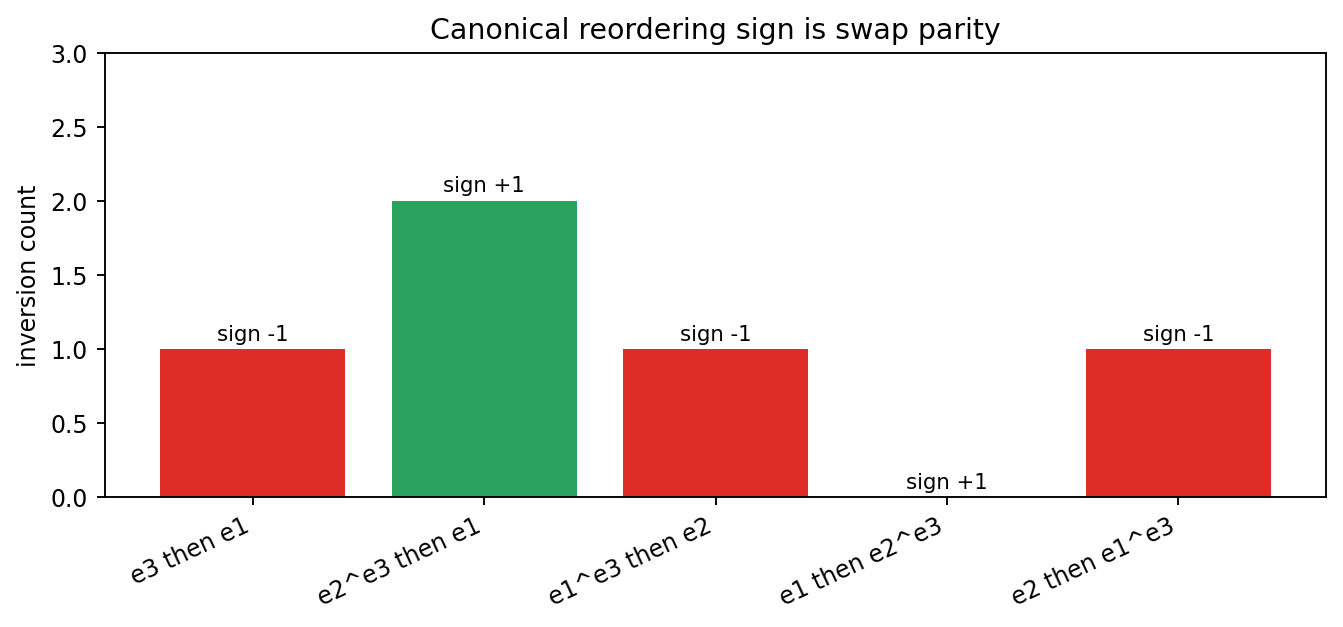

In [3]:
names3 = default_names(3)
sign_cases = [
    ("e3 then e1", BasisBlade(0b100), BasisBlade(0b001)),
    ("e2^e3 then e1", BasisBlade(0b110), BasisBlade(0b001)),
    ("e1^e3 then e2", BasisBlade(0b101), BasisBlade(0b010)),
    ("e1 then e2^e3", BasisBlade(0b001), BasisBlade(0b110)),
    ("e2 then e1^e3", BasisBlade(0b010), BasisBlade(0b101)),
]

sign_rows = []
for label, left, right in sign_cases:
    pairs = swap_pairs(left.bitmap, right.bitmap)
    sign = canonical_reordering_sign(left.bitmap, right.bitmap)
    sign_rows.append(
        {
            "case": label,
            "left": left.label(names3),
            "right": right.label(names3),
            "swap_count": len(pairs),
            "sign": sign,
            "result_bitmap": bitmap_to_label(left.bitmap ^ right.bitmap, names3),
        }
    )

fig, ax = plt.subplots(figsize=(8.0, 3.8))
x = np.arange(len(sign_rows))
swap_counts = [row["swap_count"] for row in sign_rows]
colors = ["#2ca25f" if row["sign"] > 0 else "#de2d26" for row in sign_rows]
ax.bar(x, swap_counts, color=colors)
ax.set_xticks(x, labels=[row["case"] for row in sign_rows], rotation=25, ha="right")
ax.set_ylabel("inversion count")
ax.set_title("Canonical reordering sign is swap parity")
for i, row in enumerate(sign_rows):
    ax.text(i, row["swap_count"] + 0.06, f"sign {row['sign']:+d}", ha="center", fontsize=9)
ax.set_ylim(0, max(swap_counts) + 1)
fig.tight_layout()

swap_path = FIGURE_DIR / "swap-parity.png"
fig.savefig(swap_path, dpi=170, bbox_inches="tight")
plt.close(fig)

for row in sign_rows:
    print(f"{row['left']} times {row['right']}: swaps={row['swap_count']} sign={row['sign']:+d} output={row['result_bitmap']}")

assert canonical_reordering_sign(0b100, 0b001) == -1
assert canonical_reordering_sign(0b110, 0b001) == 1
assert canonical_reordering_sign(0b101, 0b010) == -1
print(f"saved {rel(swap_path)}")
display(Image(filename=str(swap_path), width=760))

## Outer Product Of Basis Blades

The outer product asks whether two blades can span a larger independent blade. In bitmap terms this is the cleanest product in the chapter. If the bitmaps overlap, the blades share a basis-vector factor, so their outer product is zero. If the bitmaps do not overlap, the output bitmap is the exclusive-or of the two inputs, and the scale is the product of the input scales times the canonical reordering sign.

This gives a direct implementation pattern:

1. Test dependence with `left.bitmap & right.bitmap`.
2. Return zero if any bit is shared.
3. Otherwise compute `left.bitmap ^ right.bitmap`.
4. Attach the sign from swap parity.

The table below is the complete outer-product table for three dimensions. A zero entry means the inputs have a repeated basis-vector factor. Nonzero entries show the signed canonical blade. Notice how the scalar row and column behave like identity entries, while products such as `e1^e2` with `e2^e3` vanish because both contain `e2`.

In [4]:
basis3 = [BasisBlade(row["bitmap"]) for row in basis_table(3, names3)]
labels3 = [blade.label(names3) for blade in basis3]

outer_text = []
outer_grade = []
for left in basis3:
    text_row = []
    grade_row = []
    for right in basis3:
        product = outer_product_blades(left, right)
        text_row.append(blade_string(product, names3))
        grade_row.append(-1 if product.is_zero else product.grade)
    outer_text.append(text_row)
    outer_grade.append(grade_row)

fig_outer = go.Figure(
    data=go.Heatmap(
        z=outer_grade,
        x=labels3,
        y=labels3,
        text=outer_text,
        texttemplate="%{text}",
        colorscale=[
            [0.00, "#f7f7f7"],
            [0.20, "#f7f7f7"],
            [0.21, "#fee8c8"],
            [0.50, "#fdbb84"],
            [0.75, "#e34a33"],
            [1.00, "#7f0000"],
        ],
        hovertemplate="%{y} wedge %{x} = %{text}<extra></extra>",
        showscale=False,
    )
)
fig_outer.update_layout(
    title="Outer product table in 3-D",
    xaxis_title="right factor",
    yaxis_title="left factor",
    width=760,
    height=680,
)
outer_table_path = FIGURE_DIR / "outer-product-table.html"
fig_outer.write_html(outer_table_path, include_plotlyjs="cdn", full_html=True)

assert outer_product_blades(BasisBlade(0b110), BasisBlade(0b001)) == BasisBlade(0b111, 1.0)
assert outer_product_blades(BasisBlade(0b100), BasisBlade(0b001)) == BasisBlade(0b101, -1.0)
assert outer_product_blades(BasisBlade(0b001), BasisBlade(0b101)).is_zero

print(f"saved {rel(outer_table_path)}")
fig_outer

saved artifacts/chapter-19/figures/outer-product-table.html


## Geometric Product In Orthogonal Metrics

In an orthogonal metric, the geometric product differs from the outer product only when the two operands share basis-vector factors. Shared factors do not force the result to zero. Instead, each repeated basis vector contributes its metric square. With a diagonal metric `diag(m1, m2, m3)`, the repeated `e2 e2` factor contributes `m2`.

The bitmap of the result is still `left.bitmap ^ right.bitmap`: bits present in both operands are removed, and bits present in only one operand remain. The sign is still the canonical reordering sign. The new ingredient is the product of diagonal metric entries for the common bits. For Euclidean `R3`, all those entries are `+1`, so the scale is just the sign. For a mixed signature, a repeated negative-square basis vector flips the scale.

The table below is the Euclidean 3-D geometric-product table. Unlike the outer-product table, there are no zeros from repeated Euclidean basis vectors. The cell `e1^e2` times `e2` becomes `e1`, because the repeated `e2 e2` collapses to `1`. The checks also compare the specialized diagonal implementation with the general arbitrary-metric implementation, which is useful because production code often has both a fast path and a more general precomputation path.

In [5]:
metric_e3 = np.eye(3)
diag_e3 = np.diag(metric_e3)

gp_text = []
gp_sign = []
for left in basis3:
    text_row = []
    sign_row = []
    for right in basis3:
        product = geometric_product_orthogonal(left, right, diag_e3)
        text_row.append(blade_string(product, names3))
        sign_row.append(float(np.sign(product.scale)) if not product.is_zero else 0.0)
    gp_text.append(text_row)
    gp_sign.append(sign_row)

fig_gp = go.Figure(
    data=go.Heatmap(
        z=gp_sign,
        x=labels3,
        y=labels3,
        text=gp_text,
        texttemplate="%{text}",
        colorscale=[[0.0, "#b2182b"], [0.5, "#f7f7f7"], [1.0, "#2166ac"]],
        zmin=-1,
        zmax=1,
        hovertemplate="%{y} %{x} = %{text}<extra></extra>",
        showscale=False,
    )
)
fig_gp.update_layout(
    title="Geometric product table in Euclidean 3-D",
    xaxis_title="right factor",
    yaxis_title="left factor",
    width=760,
    height=680,
)
orthogonal_table_path = FIGURE_DIR / "orthogonal-geometric-product-table.html"
fig_gp.write_html(orthogonal_table_path, include_plotlyjs="cdn", full_html=True)

for left in basis3:
    for right in basis3:
        fast = geometric_product_orthogonal(left, right, diag_e3)
        general = basis_blade_geometric_product(left, right, metric_e3)
        assert close_terms(general, {fast.bitmap: fast.scale})

for a in basis3:
    for b in basis3:
        for c in basis3:
            left_assoc = multiply_multivectors(
                multiply_multivectors({a.bitmap: 1.0}, {b.bitmap: 1.0}, metric_e3),
                {c.bitmap: 1.0},
                metric_e3,
            )
            right_assoc = multiply_multivectors(
                {a.bitmap: 1.0},
                multiply_multivectors({b.bitmap: 1.0}, {c.bitmap: 1.0}, metric_e3),
                metric_e3,
            )
            assert close_terms(left_assoc, right_assoc)

mixed_e2_square = geometric_product_orthogonal(BasisBlade(0b010), BasisBlade(0b010), [1.0, -1.0, 1.0])
assert mixed_e2_square == BasisBlade(0, -1.0)

print("e1^e2 times e2 =", blade_string(geometric_product_orthogonal(BasisBlade(0b011), BasisBlade(0b010), diag_e3), names3))
print("in diag(1,-1,1), e2 times e2 =", blade_string(mixed_e2_square, names3))
print(f"saved {rel(orthogonal_table_path)}")
fig_gp

e1^e2 times e2 = e1
in diag(1,-1,1), e2 times e2 = -1
saved artifacts/chapter-19/figures/orthogonal-geometric-product-table.html


## Metric Products By Grade Selection

Once the geometric product is available, several metric products can be implemented by selecting grades from it. For basis blades, the rule is especially concrete. Compute the geometric product, then keep only the grade requested by the product definition. A scalar product keeps grade `0`. A left contraction of a grade `a` blade into a grade `b` blade, with `a <= b`, keeps grade `b-a`. A commutator product keeps half of `AB - BA`.

This is not always the fastest possible implementation. A dedicated contraction can first check whether the lower-grade blade is contained in the higher-grade blade in an orthogonal basis. But the grade-selection approach is reliable, readable, and gives a good reference implementation for tests. If a faster routine disagrees with this version on small basis blades, the faster routine is probably wrong.

The next cell collects three examples in Euclidean 3-D. It checks a left contraction, a scalar square of a bivector, and a commutator of bivectors. These are the kinds of small identities that make good unit tests for a geometric algebra library.

e1 left-contract e123: e2^e3
scalar part of e12 e12: -1
commutator of e12 and e23: e1^e3
saved artifacts/chapter-19/figures/metric-product-grade-selection.png


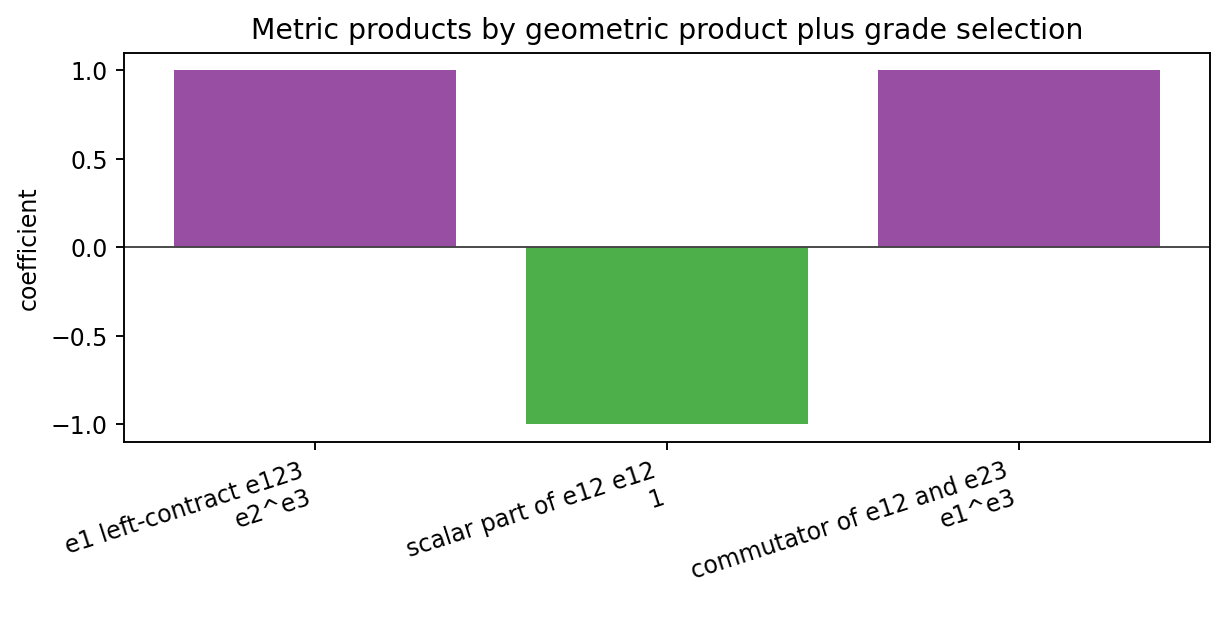

In [6]:
e1 = BasisBlade(0b001)
e2 = BasisBlade(0b010)
e3 = BasisBlade(0b100)
e12 = BasisBlade(0b011)
e23 = BasisBlade(0b110)
e123 = BasisBlade(0b111)

lc = left_contraction_blades(e1, e123, metric_e3)
scalar_e12 = scalar_product_blades(e12, e12, metric_e3)
comm_e12_e23 = commutator_blades(e12, e23, metric_e3)

metric_examples = {
    "e1 left-contract e123": lc,
    "scalar part of e12 e12": scalar_e12,
    "commutator of e12 and e23": comm_e12_e23,
}

fig, ax = plt.subplots(figsize=(7.4, 3.8))
example_names = []
coefficients = []
colors = []
for name, terms in metric_examples.items():
    for row in terms_to_rows(terms, names3):
        example_names.append(f"{name}\n{row['label']}")
        coefficients.append(float(row["coefficient"]))
        colors.append(["#4daf4a", "#377eb8", "#984ea3", "#ff7f00"][int(row["grade"])])
ax.axhline(0, color="#444444", linewidth=0.8)
ax.bar(np.arange(len(coefficients)), coefficients, color=colors)
ax.set_xticks(np.arange(len(coefficients)), labels=example_names, rotation=18, ha="right")
ax.set_ylabel("coefficient")
ax.set_title("Metric products by geometric product plus grade selection")
fig.tight_layout()

metric_products_path = FIGURE_DIR / "metric-product-grade-selection.png"
fig.savefig(metric_products_path, dpi=170, bbox_inches="tight")
plt.close(fig)

assert close_terms(lc, {0b110: 1.0})
assert close_terms(scalar_e12, {0: -1.0})
assert close_terms(comm_e12_e23, {0b101: 1.0})

for name, terms in metric_examples.items():
    print(f"{name}: {format_multivector(terms, names3)}")
print(f"saved {rel(metric_products_path)}")
display(Image(filename=str(metric_products_path), width=740))

## Nonorthogonal Metrics

The orthogonal fast path returns one weighted basis blade for every product of two basis blades. That is not true for a general metric. If the metric has off-diagonal entries, multiplying by a basis vector can create both an outer part and a contraction part. Repeating that process through a whole blade can leave several terms.

A minimal example is the two-vector null basis often used as a piece of conformal geometric algebra. Let the basis names be `o` and `inf`, with `o.o = 0`, `inf.inf = 0`, and `o.inf = inf.o = -1`. Then `o inf` has two pieces. The outer part is `o^inf`. The contraction part is the scalar `-1`. So the product is `-1 + o^inf`. Reversing the order keeps the scalar and flips the bivector sign: `inf o = -1 - o^inf`.

This is the practical reason nonorthogonal products are often precomputed. A runtime loop that assumes one output bitmap per input pair will be correct in an orthogonal basis and wrong in a null or skew basis. One remedy is to change to an orthogonal eigenbasis, compute there, and transform back. Another is to implement the arbitrary-metric product directly and cache the resulting sparse structure coefficients. The helper module uses the direct reference approach because it is compact and easy to inspect.

o inf = -1 + o^inf
inf o = -1 - o^inf
metric eigenvalues: [-1.  1.]
saved artifacts/chapter-19/figures/nonorthogonal-expansion.png
saved artifacts/chapter-19/data/nonorthogonal-product-lookup.json


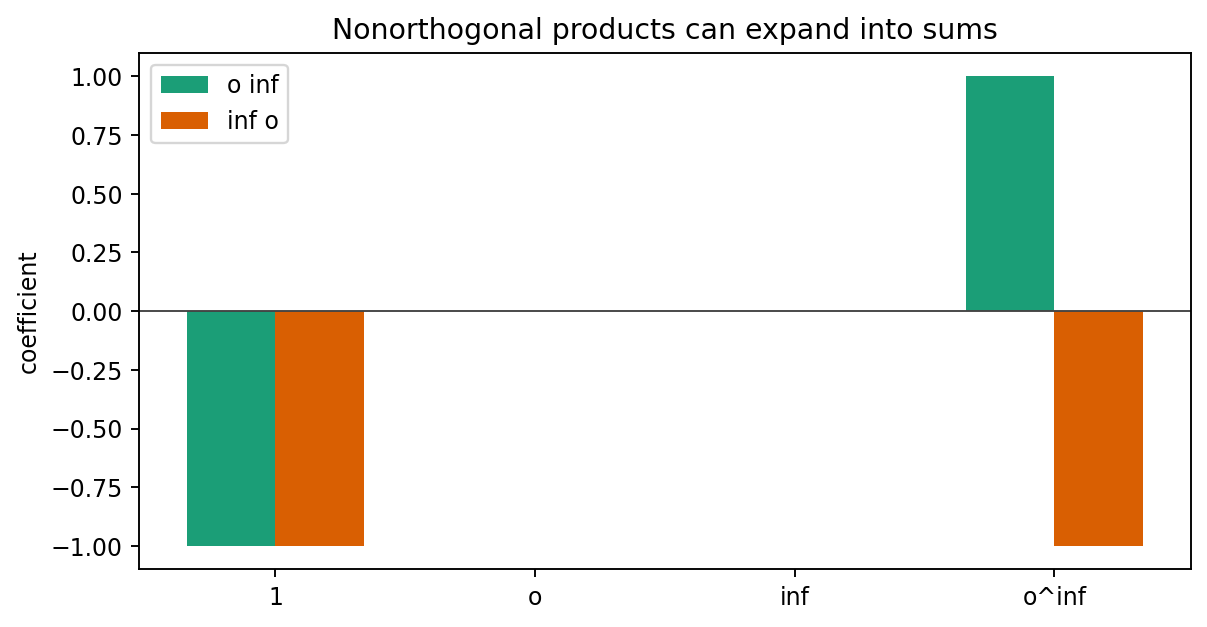

In [7]:
names_null = ("o", "inf")
metric_null = np.array([[0.0, -1.0], [-1.0, 0.0]])
o = BasisBlade(0b01)
inf = BasisBlade(0b10)

o_inf = basis_blade_geometric_product(o, inf, metric_null)
inf_o = basis_blade_geometric_product(inf, o, metric_null)
o_square = basis_blade_geometric_product(o, o, metric_null)
inf_square = basis_blade_geometric_product(inf, inf, metric_null)
eigvals, eigvecs = np.linalg.eigh(metric_null)

all_null_labels = [bitmap_to_label(bitmap, names_null) for bitmap in range(4)]
product_terms = [o_inf, inf_o]
coeff_matrix = np.array([[terms.get(bitmap, 0.0) for bitmap in range(4)] for terms in product_terms])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
width = 0.34
x = np.arange(len(all_null_labels))
ax.axhline(0, color="#444444", linewidth=0.8)
ax.bar(x - width / 2, coeff_matrix[0], width=width, label="o inf", color="#1b9e77")
ax.bar(x + width / 2, coeff_matrix[1], width=width, label="inf o", color="#d95f02")
ax.set_xticks(x, labels=all_null_labels)
ax.set_ylabel("coefficient")
ax.set_title("Nonorthogonal products can expand into sums")
ax.legend()
fig.tight_layout()

nonorth_path = FIGURE_DIR / "nonorthogonal-expansion.png"
fig.savefig(nonorth_path, dpi=170, bbox_inches="tight")
plt.close(fig)

lookup = {}
null_basis = [BasisBlade(row["bitmap"]) for row in basis_table(2, names_null)]
for left in null_basis:
    for right in null_basis:
        key = f"{left.label(names_null)} * {right.label(names_null)}"
        terms = basis_blade_geometric_product(left, right, metric_null)
        lookup[key] = terms_to_rows(terms, names_null)
lookup_path = DATA_DIR / "nonorthogonal-product-lookup.json"
lookup_path.write_text(json.dumps(lookup, indent=2, sort_keys=True), encoding="utf-8")

assert close_terms(o_inf, {0: -1.0, 0b11: 1.0})
assert close_terms(inf_o, {0: -1.0, 0b11: -1.0})
assert o_square == {}
assert inf_square == {}
assert np.allclose(eigvals, [-1.0, 1.0])

print("o inf =", format_multivector(o_inf, names_null))
print("inf o =", format_multivector(inf_o, names_null))
print("metric eigenvalues:", eigvals)
print(f"saved {rel(nonorth_path)}")
print(f"saved {rel(lookup_path)}")
display(Image(filename=str(nonorth_path), width=720))

## Applied Lab: Sparse Multivector Products

Chapter 19 works at the basis-blade level, but the reason to care is the next layer up. A sparse multivector can be represented as a dictionary from bitmap to coefficient. Multiplying two sparse multivectors means distributing over their terms, multiplying each pair of basis blades, and merging coefficients with matching output bitmaps.

This is the list-of-blades approach in miniature. It is pleasant because it naturally skips absent coordinates and keeps the code close to the mathematics. It is also expensive if used without precomputation, because every pair of nonzero terms triggers a basis-blade product. Later optimization chapters can specialize or unroll these loops. For now, the slow reference version is valuable because it is obvious enough to test.

The lab below multiplies two mixed-grade sparse multivectors in Euclidean 3-D. It also recomputes the same result manually by distributing over all term pairs, then asserts that the two paths agree. The bar chart is not just decoration: it shows which canonical blades survive after like terms are merged.

In [8]:
A = {0b001: 2.0, 0b110: 0.5}      # 2 e1 + 0.5 e2^e3
B = {0b010: -1.0, 0b101: 3.0}     # -e2 + 3 e1^e3
AB = multiply_multivectors(A, B, metric_e3)
BA = multiply_multivectors(B, A, metric_e3)

manual: dict[int, float] = {}
for a_bitmap, a_scale in A.items():
    for b_bitmap, b_scale in B.items():
        terms = basis_blade_geometric_product(BasisBlade(a_bitmap, a_scale), BasisBlade(b_bitmap, b_scale), metric_e3)
        for bitmap, scale in terms.items():
            manual[bitmap] = manual.get(bitmap, 0.0) + scale

assert close_terms(AB, manual)
assert not close_terms(AB, BA)

rows_ab = terms_to_rows(AB, names3)
fig_sparse = go.Figure(
    data=go.Bar(
        x=[row["label"] for row in rows_ab],
        y=[row["coefficient"] for row in rows_ab],
        marker_color=["#7570b3", "#1b9e77", "#d95f02", "#e7298a"][: len(rows_ab)],
        text=[f"grade {row['grade']}" for row in rows_ab],
        hovertemplate="%{x}: %{y}<br>%{text}<extra></extra>",
    )
)
fig_sparse.update_layout(
    title="Sparse multivector product A B after merging like blades",
    xaxis_title="basis blade",
    yaxis_title="coefficient",
    width=760,
    height=420,
)
sparse_path = FIGURE_DIR / "sparse-multivector-product.html"
fig_sparse.write_html(sparse_path, include_plotlyjs="cdn", full_html=True)

print("A =", format_multivector(A, names3))
print("B =", format_multivector(B, names3))
print("A B =", format_multivector(AB, names3))
print("B A =", format_multivector(BA, names3))
print(f"saved {rel(sparse_path)}")
fig_sparse

A = 2 e1 + 0.5 e2^e3
B = -e2 + 3 e1^e3
A B = 6.5 e3 - 0.5 e1^e2
B A = -6.5 e3 + 0.5 e1^e2
saved artifacts/chapter-19/figures/sparse-multivector-product.html


## Grade-Dependent Sign Operators

Reversion, grade involution, and Clifford conjugation are cheap on a basis blade because the sign depends only on grade. Once grade is `bitmap.bit_count()`, the multiplier is a small periodic pattern.

Reversion reverses the order of all vector factors in a blade. A grade-2 blade needs one swap, so it changes sign. A grade-3 blade needs three swaps, so it also changes sign. Grade involution flips odd grades and keeps even grades. Clifford conjugation combines the two patterns.

A common implementation choice is to store these sign patterns in a tiny table, or to compute them with the closed forms shown in the helper module. The table below shows grades 0 through 8. The repetition is a useful smoke test: if a sign routine fails on grade 6 or 7, the bug is likely in integer arithmetic rather than in any geometric special case.

saved artifacts/chapter-19/figures/grade-dependent-signs.png


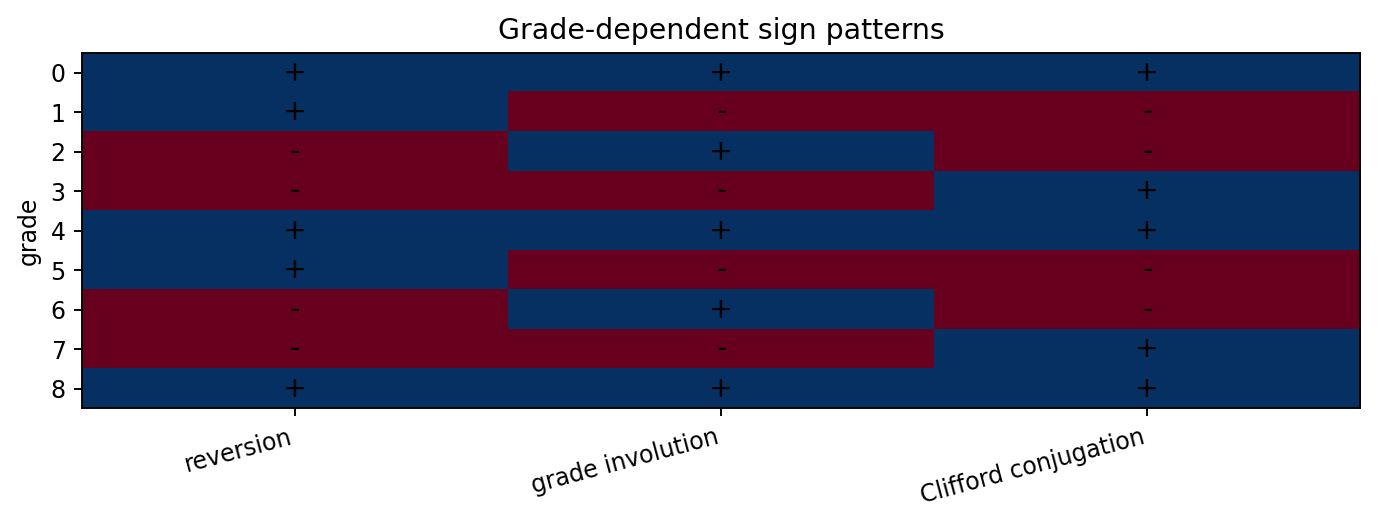

In [9]:
grades = np.arange(0, 9)
sign_names = ["reversion", "grade involution", "Clifford conjugation"]
sign_patterns = np.array(
    [
        [reversion_sign(int(g)), grade_involution_sign(int(g)), clifford_conjugation_sign(int(g))]
        for g in grades
    ]
)

fig, ax = plt.subplots(figsize=(8.2, 3.2))
ax.imshow(sign_patterns, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(3), labels=sign_names, rotation=15, ha="right")
ax.set_yticks(range(len(grades)), labels=[str(g) for g in grades])
ax.set_ylabel("grade")
ax.set_title("Grade-dependent sign patterns")
for y in range(sign_patterns.shape[0]):
    for x in range(sign_patterns.shape[1]):
        ax.text(x, y, "+" if sign_patterns[y, x] > 0 else "-", ha="center", va="center", fontsize=12)
fig.tight_layout()

signs_path = FIGURE_DIR / "grade-dependent-signs.png"
fig.savefig(signs_path, dpi=170, bbox_inches="tight")
plt.close(fig)

assert reversion_sign(2) == -1
assert reversion_sign(4) == 1
assert grade_involution_sign(5) == -1
assert clifford_conjugation_sign(3) == 1

print(f"saved {rel(signs_path)}")
display(Image(filename=str(signs_path), width=760))

## Implementation Pitfalls

The algorithms in this chapter are small, which makes it tempting to implement them from memory. The risky details are exactly the small ones.

First, keep bit order separate from printed binary order. The integer `0b101` has set bits 0 and 2, so it represents `e1^e3`, not `e3^e1`. The label function should be the single place that translates from bits to names.

Second, do not use the outer-product dependence test for the geometric product. A shared bit makes an outer product zero, but in a geometric product it produces a metric factor. In Euclidean 3-D, `e1` wedged with `e1^e3` is zero, while `e1` geometrically multiplied by `e1^e3` is `e3`.

Third, treat null squares and tiny coefficients deliberately. In the null basis above, `o o` is zero because the metric says `o.o = 0`, not because the bitmap code failed. Real implementations need an epsilon policy when simplifying floating-point coefficients.

Fourth, never assume a basis-blade product is one basis blade unless the metric path guarantees it. Orthogonal products have that property. Nonorthogonal products can expand into sums, and downstream lookup tables or matrix builders need to store all resulting terms.

The next cell turns those pitfalls into executable checks and writes a JSON artifact so the final sanity cell can verify them again.

In [10]:
pitfall_checks = {
    "bit_order_0b101_label": bitmap_to_label(0b101, names3),
    "outer_duplicate_zero": outer_product_blades(e1, BasisBlade(0b101)).is_zero,
    "geometric_duplicate_result": format_multivector(
        basis_blade_geometric_product(e1, BasisBlade(0b101), metric_e3), names3
    ),
    "null_o_square_terms": terms_to_rows(o_square, names_null),
    "nonorthogonal_product_term_count": len(o_inf),
}

assert pitfall_checks["bit_order_0b101_label"] == "e1^e3"
assert pitfall_checks["outer_duplicate_zero"] is True
assert pitfall_checks["geometric_duplicate_result"] == "e3"
assert pitfall_checks["null_o_square_terms"] == []
assert pitfall_checks["nonorthogonal_product_term_count"] == 2

pitfalls_path = CHECK_DIR / "pitfall-checks.json"
pitfalls_path.write_text(json.dumps(pitfall_checks, indent=2, sort_keys=True), encoding="utf-8")

print(json.dumps(pitfall_checks, indent=2))
print(f"saved {rel(pitfalls_path)}")

{
  "bit_order_0b101_label": "e1^e3",
  "outer_duplicate_zero": true,
  "geometric_duplicate_result": "e3",
  "null_o_square_terms": [],
  "nonorthogonal_product_term_count": 2
}
saved artifacts/chapter-19/checks/pitfall-checks.json


## Final Sanity Checks

The notebook has now exercised the main basis-blade implementation ideas: bitmap encoding, grade counting, swap parity, outer products, diagonal-metric geometric products, nonorthogonal expansions, sparse multivector distribution, and grade-dependent signs.

The final cell checks invariants across the whole run and verifies that every promised artifact exists. This is intentionally a little redundant. A chapter-replacement notebook should be readable, but it should also be runnable as a compact regression test for its own helper code.

In [11]:
expected_artifacts = [
    bitmap_path,
    swap_path,
    outer_table_path,
    orthogonal_table_path,
    metric_products_path,
    nonorth_path,
    lookup_path,
    sparse_path,
    signs_path,
    pitfalls_path,
]

assert len(rows4) == 16
assert all(row["grade"] == int(row["bitmap"]).bit_count() for row in rows4)
assert canonical_reordering_sign(0b111, 0b111) == -1
assert close_terms(o_inf, {0: -1.0, 0b11: 1.0})
assert close_terms(AB, manual)
assert close_terms(grade_project({0: -1.0, 0b11: 1.0}, 0), {0: -1.0})

missing_before_sanity = [rel(path) for path in expected_artifacts if not path.exists()]
assert not missing_before_sanity, missing_before_sanity

sanity = {
    "source_span": SOURCE_SPAN,
    "basis_rows_4d": len(rows4),
    "outer_product_examples_checked": 3,
    "orthogonal_table_entries": len(basis3) ** 2,
    "associativity_checked_triples": len(basis3) ** 3,
    "nonorthogonal_o_inf": format_multivector(o_inf, names_null),
    "sparse_product_AB": format_multivector(AB, names3),
    "artifacts": [rel(path) for path in expected_artifacts],
}
sanity_path = CHECK_DIR / "chapter19-sanity.json"
sanity_path.write_text(json.dumps(sanity, indent=2, sort_keys=True), encoding="utf-8")
expected_artifacts.append(sanity_path)

missing = [rel(path) for path in expected_artifacts if not path.exists()]
assert not missing, missing

print("final sanity checks passed")
print(json.dumps(sanity, indent=2))
print(f"saved {rel(sanity_path)}")

final sanity checks passed
{
  "source_span": {
    "printed_pages_requested": "511-520",
    "pdf_pages_extracted": "533-541",
    "note": "Printed page 520 is blank or unextracted; PDF page 542 begins printed page 521."
  },
  "basis_rows_4d": 16,
  "outer_product_examples_checked": 3,
  "orthogonal_table_entries": 64,
  "associativity_checked_triples": 512,
  "nonorthogonal_o_inf": "-1 + o^inf",
  "sparse_product_AB": "6.5 e3 - 0.5 e1^e2",
  "artifacts": [
    "artifacts/chapter-19/figures/bitmap-encoding.png",
    "artifacts/chapter-19/figures/swap-parity.png",
    "artifacts/chapter-19/figures/outer-product-table.html",
    "artifacts/chapter-19/figures/orthogonal-geometric-product-table.html",
    "artifacts/chapter-19/figures/metric-product-grade-selection.png",
    "artifacts/chapter-19/figures/nonorthogonal-expansion.png",
    "artifacts/chapter-19/data/nonorthogonal-product-lookup.json",
    "artifacts/chapter-19/figures/sparse-multivector-product.html",
    "artifacts/chapte

## Chapter Takeaways

A basis-blade implementation is a compact contract between algebra and machine representation. The bitmap names the canonical blade. The scale carries weight and orientation. Grade is a bit count. Dependence is a bitwise `and`. Combining independent factors is exclusive-or. The sign is inversion parity, not a decorative detail.

For orthogonal metrics, the geometric product remains especially lean: the output bitmap is still exclusive-or, and repeated basis vectors contribute diagonal metric factors. This is why specialized Euclidean and mixed-signature implementations can be extremely fast.

For nonorthogonal metrics, the product must allow expansion. A single pair of basis blades may produce a scalar plus a bivector, or more terms in higher dimensions. Correct implementations either change basis, precompute the full table of structure coefficients, or use a direct arbitrary-metric routine like the reference helper here.

The chapter's practical lesson is to make the basis-blade layer boringly reliable. Once these products are correct, the next implementation layer can distribute them across sparse multivectors, build product matrices, implement contractions and commutators by grade selection, and optimize with confidence. If these low-level signs or metric factors are wrong, every beautiful geometric construction above them inherits the mistake.